# 챗봇 시스템 설계 사례 분해해보기

## 챗봇 아키텍처 유형 비교

| 유형 | 방식 | 장점 | 단점 | 사례 |
|------|------|------|------|------|
| **Rule-based** | 규칙/패턴 매칭 | 예측 가능, 빠름 | 유연성 부족 | 초기 Siri |
| **Retrieval-based** | 유사 응답 검색 | 품질 보장 | 새 질문 대응 못함 | FAQ 봇 |
| **Generative** | Seq2Seq 생성 | 유연한 응답 | 환각(hallucination) | ChatGPT |
| **Hybrid** | 규칙 + ML 결합 | 균형 잡힌 성능 | 복잡한 설계 | Google Assistant |

## 실제 챗봇 시스템 구조 (파이프라인)

```
사용자 입력
    │
    ▼
① NLU (자연어 이해)
   ├─ 전처리 (토큰화, 정규화)
   ├─ 의도 분류 (Intent Classification)
   └─ 개체명 인식 (Entity Extraction)
    │
    ▼
② 대화 관리 (Dialogue Management)
   ├─ 상태 추적 (State Tracking)
   └─ 정책 결정 (Policy)
    │
    ▼
③ NLG (자연어 생성)
   └─ 템플릿 / 신경망 생성
    │
    ▼
시스템 응답
```

In [1]:
# 필요 라이브러리
import re
import json
import random
import numpy as np
from collections import defaultdict, Counter
import warnings
warnings.filterwarnings('ignore')

random.seed(42)
np.random.seed(42)
print('✅ 라이브러리 로드 완료')

✅ 라이브러리 로드 완료


## 1️⃣ 사례 분해: 고객 서비스 챗봇 (은행/커머스)

### 실제 사례 분석

| 회사 | 챗봇명 | 기술 스택 | 주요 기능 |
|------|--------|----------|----------|
| **카카오뱅크** | 상담봇 | BERT + 규칙 | 계좌조회, 이체 안내 |
| **쿠팡** | 주문봇 | 의도분류 + 슬롯필링 | 배송조회, 반품 |
| **네이버** | 클로바 | LLM + RAG | 일반 QA |
| **라인** | 라인봇 | Seq2Seq | 감성 대화 |

### 공통 설계 요소 분해
```
1. 의도(Intent) 정의    → 무엇을 원하는가?
2. 슬롯(Slot) 정의      → 어떤 정보가 필요한가?
3. 대화 흐름 설계       → 어떻게 진행할 것인가?
4. 예외 처리            → 모르는 경우 어떻게 하는가?
5. 컨텍스트 관리        → 이전 대화를 어떻게 활용하는가?
```

In [2]:
# ──────────────────────────────────────────────────────
# 사례 분해 ①: 의도(Intent) + 슬롯(Slot) 정의
# 실제 커머스 챗봇 인텐트 구조
# ──────────────────────────────────────────────────────

INTENT_SCHEMA = {
    'order_status': {
        'description': '주문 배송 상태 조회',
        'slots': {
            'order_number': {'type': 'string', 'required': True,  'prompt': '주문 번호를 알려주세요.'},
            'product_name': {'type': 'string', 'required': False, 'prompt': '어떤 상품인가요?'},
        },
        'examples': [
            '내 주문 어디까지 왔어요?',
            '배송 현황 알고 싶어요',
            '주문번호 12345 배송 추적',
        ]
    },
    'refund_request': {
        'description': '환불/반품 요청',
        'slots': {
            'order_number': {'type': 'string', 'required': True,  'prompt': '환불할 주문 번호를 알려주세요.'},
            'reason':       {'type': 'string', 'required': True,  'prompt': '환불 사유가 무엇인가요?'},
            'product_name': {'type': 'string', 'required': False, 'prompt': '어떤 상품을 환불하시겠어요?'},
        },
        'examples': [
            '환불하고 싶어요',
            '상품이 파손되어서 반품하려고요',
            '주문 취소 해주세요',
        ]
    },
    'product_inquiry': {
        'description': '상품 정보 문의',
        'slots': {
            'product_name': {'type': 'string', 'required': True, 'prompt': '어떤 상품이 궁금하신가요?'},
            'attribute':    {'type': 'enum',   'required': False, 'values': ['가격', '재고', '사이즈', '색상']},
        },
        'examples': [
            '이 상품 재고 있나요?',
            '가격 얼마예요?',
            '사이즈 어떻게 되나요?',
        ]
    },
    'greeting': {
        'description': '인사',
        'slots': {},
        'examples': ['안녕하세요', '반갑습니다', '도움 요청', '챗봇 불러줘']
    },
    'farewell': {
        'description': '대화 종료',
        'slots': {},
        'examples': ['감사합니다', '수고하세요', '종료', '잘가요']
    },
    'unknown': {
        'description': '인식 불가',
        'slots': {},
        'examples': []
    }
}

print('[챗봇 인텐트 스키마]')
print(f'총 인텐트: {len(INTENT_SCHEMA)}개\n')
for intent, info in INTENT_SCHEMA.items():
    slots = list(info['slots'].keys())
    required = [s for s, v in info['slots'].items() if v.get('required')]
    print(f'  [{intent}] {info["description"]}')
    if slots:
        print(f'    슬롯: {slots}  (필수: {required})')
    if info['examples']:
        print(f'    예시: "{info["examples"][0]}"')
    print()

[챗봇 인텐트 스키마]
총 인텐트: 6개

  [order_status] 주문 배송 상태 조회
    슬롯: ['order_number', 'product_name']  (필수: ['order_number'])
    예시: "내 주문 어디까지 왔어요?"

  [refund_request] 환불/반품 요청
    슬롯: ['order_number', 'reason', 'product_name']  (필수: ['order_number', 'reason'])
    예시: "환불하고 싶어요"

  [product_inquiry] 상품 정보 문의
    슬롯: ['product_name', 'attribute']  (필수: ['product_name'])
    예시: "이 상품 재고 있나요?"

  [greeting] 인사
    예시: "안녕하세요"

  [farewell] 대화 종료
    예시: "감사합니다"

  [unknown] 인식 불가



## 2️⃣ NLU 모듈 구현 — 의도 분류 (Rule-based + ML)

### 의도 분류 방법
```
Level 1: 키워드 매칭 (빠름, 간단)
Level 2: TF-IDF + 코사인 유사도 (중간)
Level 3: 신경망 분류기 (정확, 느림)
```

In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
import numpy as np


# ── Level 1: 키워드 기반 의도 분류 ──────────────────────────
INTENT_KEYWORDS = {
    'order_status':    ['배송', '주문', '어디', '현황', '추적', '언제', '도착'],
    'refund_request':  ['환불', '반품', '취소', '파손', '불량', '교환', '돌려'],
    'product_inquiry': ['재고', '가격', '얼마', '사이즈', '색상', '정보', '있나'],
    'greeting':        ['안녕', '반갑', '안녕하세요', '도움', '챗봇'],
    'farewell':        ['감사', '수고', '종료', '잘가', '바이', '끝'],
}

def keyword_intent_classifier(text: str) -> str:
    scores = {intent: 0 for intent in INTENT_KEYWORDS}
    for intent, keywords in INTENT_KEYWORDS.items():
        for kw in keywords:
            if kw in text:
                scores[intent] += 1
    best = max(scores, key=scores.get)
    return best if scores[best] > 0 else 'unknown'


# ── Level 2: TF-IDF 유사도 기반 의도 분류 ───────────────────
# 학습 데이터: 각 인텐트의 예시 문장
TRAINING_DATA_EXTENDED = {
    'order_status': [
        '내 주문 어디까지 왔어요', '배송 현황 알고 싶어요', '주문번호 12345 배송 추적',
        '배송이 언제 오나요', '내 택배 확인해줘', '주문한 물건 도착했나요',
        '배달 얼마나 걸려요', '지금 어디 있어요 택배', '배송 조회 해주세요',
    ],
    'refund_request': [
        '환불하고 싶어요', '상품이 파손되어서 반품하려고요', '주문 취소 해주세요',
        '교환 신청하고 싶어요', '불량품 받았어요', '환불 신청 방법 알려주세요',
        '마음에 안들어서 반품할게요', '취소 가능한가요', '환불 얼마나 걸려요',
    ],
    'product_inquiry': [
        '이 상품 재고 있나요', '가격 얼마예요', '사이즈 어떻게 되나요',
        '색상 종류 알려주세요', '이거 품절인가요', '할인 중인가요',
        '성분이 뭔가요', '원산지가 어디예요', '스펙이 뭔가요',
    ],
    'greeting': [
        '안녕하세요', '반갑습니다', '도움 받고 싶어요', '챗봇 연결해주세요',
        '상담원 연결', '안녕', '처음 써봐요', '무엇을 도와줄 수 있나요',
    ],
    'farewell': [
        '감사합니다', '수고하세요', '도움 많이 됐어요', '해결됐어요',
        '종료할게요', '잘가요', '바이바이', '대화 끝낼게요',
    ],
}

# TF-IDF 벡터화 + ML 분류기
train_texts, train_labels = [], []
for intent, examples in TRAINING_DATA_EXTENDED.items():
    train_texts.extend(examples)
    train_labels.extend([intent] * len(examples))

tfidf_clf = Pipeline([
    ('tfidf', TfidfVectorizer(analyzer='char_wb', ngram_range=(2,4))),
    ('clf',   MultinomialNB(alpha=0.5))
])
tfidf_clf.fit(train_texts, train_labels)


def tfidf_intent_classifier(text: str) -> tuple[str, float]:
    proba = tfidf_clf.predict_proba([text])[0]
    pred  = tfidf_clf.predict([text])[0]
    conf  = max(proba)
    if conf < 0.2:
        return 'unknown', conf
    return pred, conf


# ── 테스트 ────────────────────────────────────────────────
test_inputs = [
    '내 택배 지금 어디쯤 왔나요?',
    '사이즈가 안 맞아서 교환하고 싶어요',
    '이 신발 검정색 있어요?',
    '안녕하세요! 도움이 필요해요',
    '감사합니다 잘 해결됐어요',
    '오늘 날씨 어때요?',  # unknown
]

print('[의도 분류 비교 테스트]\n')
print(f"{'입력':>28} | {'키워드':>16} | {'TF-IDF + 신뢰도':>22}")
print('=' * 75)
for text in test_inputs:
    kw_result    = keyword_intent_classifier(text)
    ml_result, conf = tfidf_intent_classifier(text)
    print(f"  {text:<26} | {kw_result:<16} | {ml_result:<14} ({conf:.2f})")

[의도 분류 비교 테스트]

                          입력 |              키워드 |           TF-IDF + 신뢰도
  내 택배 지금 어디쯤 왔나요?           | order_status     | order_status   (0.65)
  사이즈가 안 맞아서 교환하고 싶어요        | refund_request   | refund_request (0.40)
  이 신발 검정색 있어요?              | unknown          | order_status   (0.27)
  안녕하세요! 도움이 필요해요            | greeting         | greeting       (0.57)
  감사합니다 잘 해결됐어요              | farewell         | farewell       (0.74)
  오늘 날씨 어때요?                 | unknown          | order_status   (0.30)


## 3️⃣ NLU 모듈 — 개체명/슬롯 추출 (Entity Extraction)

In [4]:
# 정규표현식 기반 슬롯 추출
SLOT_PATTERNS = {
    'order_number': [
        r'주문\s*번호\s*[:\s]?\s*([A-Z0-9\-]{4,15})',
        r'([A-Z]{2}\d{8,12})',           # 예: KR202312340001
        r'(\d{5,12})번',                  # 예: 12345번
        r'번호\s+(\d+)',
    ],
    'phone_number': [
        r'(010[-\s]?\d{4}[-\s]?\d{4})',
        r'(\d{3}-\d{3,4}-\d{4})',
    ],
    'date': [
        r'(\d{4}[./-]\d{1,2}[./-]\d{1,2})',
        r'(\d{1,2}월\s*\d{1,2}일)',
        r'(오늘|내일|어제|모레)',
    ],
    'price': [
        r'(\d+)원',
        r'(\d+,\d+)원',
    ],
    'refund_reason': {
        'keywords': {
            '파손': 'damaged',
            '불량': 'defective',
            '색상': 'wrong_color',
            '사이즈': 'wrong_size',
            '마음에 안': 'changed_mind',
            '품질': 'poor_quality',
        }
    }
}

def extract_slots(text: str, intent: str) -> dict:
    extracted = {}

    # 패턴 기반 추출
    for slot, patterns in SLOT_PATTERNS.items():
        if isinstance(patterns, list):
            for pat in patterns:
                m = re.search(pat, text)
                if m:
                    extracted[slot] = m.group(1)
                    break
        elif isinstance(patterns, dict) and 'keywords' in patterns:
            for kw, label in patterns['keywords'].items():
                if kw in text:
                    extracted[slot] = label
                    break

    return extracted


# 테스트
slot_tests = [
    ('주문번호 KR20231234001 배송 언제 오나요?', 'order_status'),
    ('12345번 주문 환불하고 싶어요 상품이 파손됐어요', 'refund_request'),
    ('010-1234-5678로 연락주세요', 'general'),
    ('12월 25일에 주문한 거 아직 안 왔어요', 'order_status'),
]

print('[슬롯 추출 테스트]\n')
for text, intent in slot_tests:
    slots = extract_slots(text, intent)
    print(f'  입력: "{text}"')
    print(f'  추출: {slots}\n')

[슬롯 추출 테스트]

  입력: "주문번호 KR20231234001 배송 언제 오나요?"
  추출: {'order_number': 'KR20231234001'}

  입력: "12345번 주문 환불하고 싶어요 상품이 파손됐어요"
  추출: {'order_number': '12345', 'refund_reason': 'damaged'}

  입력: "010-1234-5678로 연락주세요"
  추출: {'phone_number': '010-1234-5678'}

  입력: "12월 25일에 주문한 거 아직 안 왔어요"
  추출: {'date': '12월 25일'}



## 4️⃣ 대화 관리 모듈 — 상태 기계(FSM) 기반

```
[idle] → greeting → [ask_intent] → intent분류
                                        │
                    ┌───────────────────┤
                    │ order_status      │ refund_request
                    ▼                   ▼
            [ask_order_num]    [ask_order_num]
                    │                   │
                    ▼                   ▼
            [show_status]      [ask_reason]
                    │                   │
                    └─────┬─────────────┘
                          ▼
                    [confirm_done] → farewell
```

In [5]:
class DialogueState:
    """대화 상태 추적기"""
    def __init__(self):
        self.intent     = None
        self.slots      = {}
        self.stage      = 'idle'          # idle→greeting→slot_filling→action→done
        self.turn_count = 0
        self.history    = []              # (역할, 발화) 리스트
        self.pending_slot = None          # 현재 채워야 할 슬롯

    def update(self, user_text: str, detected_intent: str, extracted_slots: dict):
        self.turn_count += 1
        self.history.append(('user', user_text))
        if detected_intent != 'unknown':
            self.intent = detected_intent
        self.slots.update({k: v for k, v in extracted_slots.items() if v})

    def missing_required_slots(self) -> list:
        if not self.intent or self.intent not in INTENT_SCHEMA:
            return []
        required = [
            slot for slot, meta in INTENT_SCHEMA[self.intent]['slots'].items()
            if meta.get('required') and slot not in self.slots
        ]
        return required

    def add_response(self, response: str):
        self.history.append(('bot', response))

    def reset(self):
        self.__init__()

    def __repr__(self):
        return (f'State(intent={self.intent}, stage={self.stage}, '
                f'slots={self.slots}, turn={self.turn_count})')


# ── 응답 템플릿 ────────────────────────────────────────────
RESPONSE_TEMPLATES = {
    'greeting': [
        '안녕하세요! 쇼핑몰 고객센터입니다 😊 무엇을 도와드릴까요?',
        '반갑습니다! 어떤 도움이 필요하신가요?',
    ],
    'farewell': [
        '감사합니다. 더 필요하신 게 있으면 언제든지 찾아주세요! 👋',
        '문의해 주셔서 감사합니다. 좋은 하루 되세요!',
    ],
    'ask_order_number': '주문 번호를 알려주시겠어요? (예: KR202312340001)',
    'ask_refund_reason': '환불/반품 사유를 알려주시겠어요?\n(파손/불량/사이즈/단순변심 등)',
    'order_status_result': '주문번호 {order_number}의 배송 현황을 조회했습니다.\n'
                           '📦 현재 상태: 배송 중 (대구 물류센터 출발)\n'
                           '예상 도착일: 내일 오후',
    'refund_complete': '환불 신청이 완료되었습니다.\n'
                       '💳 환불 처리까지 영업일 기준 3~5일 소요됩니다.',
    'unknown': [
        '죄송합니다, 잘 이해하지 못했어요. 다시 말씀해 주시겠어요?',
        '이해하기 어려운 질문이네요. 조금 더 구체적으로 말씀해 주세요.',
    ],
    'fallback_human': '해당 내용은 상담원이 직접 도와드려야 할 것 같습니다.\n'
                      '📞 고객센터: 1588-0000 (평일 9시~18시)',
}

print('대화 상태 관리 모듈 준비 완료!')

대화 상태 관리 모듈 준비 완료!


## 5️⃣ 챗봇 엔진 통합 — 전체 파이프라인

In [8]:
class ChatbotEngine:
    """
    챗봇 시스템 설계 분해:
    NLU → Dialogue Manager → NLG
    """

    def __init__(self):
        self.state   = DialogueState()
        self.max_turns_per_intent = 5

    # ── NLU ──────────────────────────────────────────
    def _nlu(self, text: str) -> tuple[str, float, dict]:
        """자연어 이해: 의도 + 슬롯 추출"""
        intent, conf = tfidf_intent_classifier(text)
        # 키워드로 보정
        if conf < 0.3:
            kw_intent = keyword_intent_classifier(text)
            if kw_intent != 'unknown':
                intent, conf = kw_intent, 0.5
        slots = extract_slots(text, intent)
        return intent, conf, slots

    # ── 대화 관리 ──────────────────────────────────────
    def _dialogue_manage(self, intent: str, conf: float, slots: dict) -> str:
        """대화 정책 결정: 다음 액션 반환"""
        state = self.state

        # idle 상태 → 인사
        if state.stage == 'idle':
            state.stage = 'active'
            if intent in ('greeting', 'unknown'):
                return 'greet'

        # 인사/종료 의도
        if intent == 'greeting':  return 'greet'
        if intent == 'farewell':  return 'farewell'

        # 의도 미파악
        if intent == 'unknown':   return 'unknown'

        # 슬롯 필링 진행
        missing = state.missing_required_slots()
        if missing:
            return f'ask_slot:{missing[0]}'

        # 모든 필수 슬롯 채워짐 → 실행
        return f'execute:{intent}'

    # ── NLG ───────────────────────────────────────────
    def _nlg(self, action: str) -> str:
        """자연어 생성: 액션 → 응답 텍스트"""
        tmpl = RESPONSE_TEMPLATES
        state = self.state

        if action == 'greet':
            return random.choice(tmpl['greeting'])
        if action == 'farewell':
            return random.choice(tmpl['farewell'])
        if action == 'unknown':
            if state.turn_count >= 3:
                return tmpl['fallback_human']
            return random.choice(tmpl['unknown'])
        if action.startswith('ask_slot:'):
            slot_name = action.split(':')[1]
            if slot_name == 'order_number': return tmpl['ask_order_number']
            if slot_name == 'reason':       return tmpl['ask_refund_reason']
            # 스키마에서 프롬프트 가져오기
            if state.intent and slot_name in INTENT_SCHEMA.get(state.intent, {}).get('slots', {}):
                return INTENT_SCHEMA[state.intent]['slots'][slot_name].get('prompt', f'{slot_name}을 알려주세요.')
        if action.startswith('execute:'):
            intent = action.split(':')[1]
            if intent == 'order_status':
                return tmpl['order_status_result'].format(**state.slots)
            if intent == 'refund_request':
                return tmpl['refund_complete']
            if intent == 'product_inquiry':
                product = state.slots.get('product_name', '해당 상품')
                return f"'{product}' 상품 정보를 조회합니다.\n💡 현재 재고 있음 / 정상가 59,000원"
        return '처리 중 오류가 발생했습니다. 잠시 후 다시 시도해 주세요.'

    # ── 메인 응답 함수 ─────────────────────────────────
    def respond(self, user_text: str, verbose: bool = True) -> str:
        # 1. NLU
        intent, conf, slots = self._nlu(user_text)
        self.state.update(user_text, intent, slots)

        # 2. 대화 관리
        action = self._dialogue_manage(intent, conf, slots)

        # 3. NLG
        response = self._nlg(action)
        self.state.add_response(response)

        if verbose:
            print(f'  🔍 NLU: intent={intent}({conf:.2f}), slots={slots}')
            print(f'  ⚙️  DM:  action={action}')
            print(f'  💬 Bot: {response}')
            print(f'  📊 State: {self.state}\n')

        return response

    def reset(self):
        self.state.reset()


print('챗봇 엔진 준비 완료!')

챗봇 엔진 준비 완료!


## 6️⃣ 시나리오 테스트 — 실제 대화 흐름

In [9]:
def run_scenario(scenario_name: str, turns: list):
    print(f'{'='*60}')
    print(f'  🎬 시나리오: {scenario_name}')
    print(f'{'='*60}')
    bot = ChatbotEngine()
    for user_input in turns:
        print(f'👤 User: {user_input}')
        bot.respond(user_input, verbose=True)
    print(f'📈 총 {bot.state.turn_count}턴 대화 완료\n')


# 시나리오 1: 배송 조회 (Happy Path)
run_scenario('배송 조회 (정상 흐름)', [
    '안녕하세요',
    '제 주문 배송 현황 알고 싶어요',
    '주문번호는 KR20231234001이에요',
    '감사합니다',
])

# 시나리오 2: 환불 요청
run_scenario('환불 요청 (슬롯 필링)', [
    '상품이 파손되어서 환불하고 싶어요',
    '주문번호는 12345번이에요',
    '감사해요 잘 해결됐어요',
])

# 시나리오 3: 인식 불가 → Fallback
run_scenario('인식 불가 → Human Handoff', [
    '오늘 날씨 어때요?',
    '주식 시세 알려줘',
    '요즘 뭐가 유행이야?',
])

  🎬 시나리오: 배송 조회 (정상 흐름)
👤 User: 안녕하세요
  🔍 NLU: intent=greeting(0.58), slots={}
  ⚙️  DM:  action=greet
  💬 Bot: 안녕하세요! 쇼핑몰 고객센터입니다 😊 무엇을 도와드릴까요?
  📊 State: State(intent=greeting, stage=active, slots={}, turn=1)

👤 User: 제 주문 배송 현황 알고 싶어요
  🔍 NLU: intent=order_status(0.64), slots={}
  ⚙️  DM:  action=ask_slot:order_number
  💬 Bot: 주문 번호를 알려주시겠어요? (예: KR202312340001)
  📊 State: State(intent=order_status, stage=active, slots={}, turn=2)

👤 User: 주문번호는 KR20231234001이에요
  🔍 NLU: intent=order_status(0.45), slots={'order_number': 'KR20231234001'}
  ⚙️  DM:  action=execute:order_status
  💬 Bot: 주문번호 KR20231234001의 배송 현황을 조회했습니다.
📦 현재 상태: 배송 중 (대구 물류센터 출발)
예상 도착일: 내일 오후
  📊 State: State(intent=order_status, stage=active, slots={'order_number': 'KR20231234001'}, turn=3)

👤 User: 감사합니다
  🔍 NLU: intent=farewell(0.55), slots={}
  ⚙️  DM:  action=farewell
  💬 Bot: 감사합니다. 더 필요하신 게 있으면 언제든지 찾아주세요! 👋
  📊 State: State(intent=farewell, stage=active, slots={'order_number': 'KR20231234001'}, turn=4)

📈 총 4

## 7️⃣ 챗봇 시스템 평가 지표

[의도 분류 평가]
  키워드 기반: 8/8 = 100.0%
  TF-IDF ML:  8/8 = 100.0%


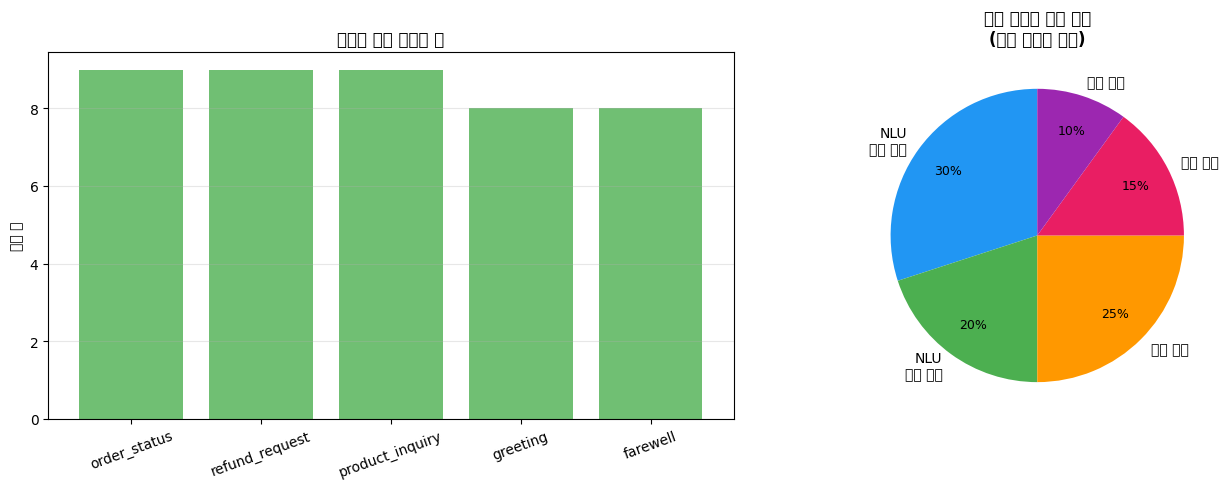

In [10]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'NanumGothic' if 'NanumGothic' in matplotlib.font_manager.get_font_names() else 'DejaVu Sans'
matplotlib.rcParams['axes.unicode_minus'] = False

# 의도 분류 정확도 평가
eval_set = [
    ('배송이 언제 와요?', 'order_status'),
    ('내 택배 추적해줘', 'order_status'),
    ('환불하고 싶어요', 'refund_request'),
    ('불량품 반품', 'refund_request'),
    ('이 상품 재고 있나요?', 'product_inquiry'),
    ('가격이 얼마예요?', 'product_inquiry'),
    ('안녕하세요', 'greeting'),
    ('감사합니다', 'farewell'),
]

correct_kw = sum(1 for t, l in eval_set if keyword_intent_classifier(t) == l)
correct_ml = sum(1 for t, l in eval_set if tfidf_intent_classifier(t)[0] == l)

print('[의도 분류 평가]')
print(f'  키워드 기반: {correct_kw}/{len(eval_set)} = {correct_kw/len(eval_set)*100:.1f}%')
print(f'  TF-IDF ML:  {correct_ml}/{len(eval_set)} = {correct_ml/len(eval_set)*100:.1f}%')

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 의도별 샘플 수
intent_counts = Counter(train_labels)
axes[0].bar(intent_counts.keys(), intent_counts.values(), color='#4CAF50', alpha=0.8)
axes[0].set_title('의도별 학습 데이터 수', fontsize=12, fontweight='bold')
axes[0].set_ylabel('샘플 수')
axes[0].tick_params(axis='x', rotation=20)
axes[0].grid(axis='y', alpha=0.3)

# 챗봇 구성 요소 비중 (가상)
components = ['NLU\n의도 분류', 'NLU\n슬롯 추출', '대화 관리', '응답 생성', '에러 처리']
complexity = [30, 20, 25, 15, 10]
colors_pie = ['#2196F3','#4CAF50','#FF9800','#E91E63','#9C27B0']
wedges, texts, autotexts = axes[1].pie(
    complexity, labels=components, colors=colors_pie,
    autopct='%1.0f%%', startangle=90, pctdistance=0.75
)
for t in autotexts: t.set_fontsize(9)
axes[1].set_title('챗봇 시스템 구성 요소\n(개발 복잡도 비중)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('chatbot_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 8️⃣ 설계 사례 요약 정리

In [11]:
summary = """
╔══════════════════════════════════════════════════════════════╗
║           챗봇 시스템 설계 사례 분해 요약                        ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  [1] NLU (자연어 이해)                                         ║
║      • 의도 분류: 키워드 → TF-IDF → BERT (정확도 순)             ║
║      • 슬롯 추출: 정규식 → NER 모델                              ║
║      • 신뢰도 임계값으로 fallback 처리 필수                       ║
║                                                              ║
║  [2] 대화 관리 (Dialogue Manager)                              ║
║      • 상태 추적: 의도 + 슬롯 + 대화 단계 관리                    ║
║      • 슬롯 필링: 필수 정보를 순차적으로 수집                      ║
║      • 다중 턴 컨텍스트: 이전 발화 정보 재사용                     ║
║                                                              ║
║  [3] NLG (자연어 생성)                                         ║
║      • 템플릿 기반: 일관성 ↑, 유연성 ↓                           ║
║      • 신경망 생성: 유연성 ↑, 환각 위험 ↑                        ║
║                                                              ║
║  [4] 핵심 설계 원칙                                             ║
║      • Graceful Degradation: 모르면 사람에게 연결                ║
║      • 최소 턴으로 목표 달성 (3턴 이내 권장)                      ║
║      • 명확한 에러 메시지와 재시도 유도                            ║
║      • 개인정보 슬롯 수집 최소화                                  ║
╚══════════════════════════════════════════════════════════════╝
"""
print(summary)


╔══════════════════════════════════════════════════════════════╗
║           챗봇 시스템 설계 사례 분해 요약                        ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  [1] NLU (자연어 이해)                                         ║
║      • 의도 분류: 키워드 → TF-IDF → BERT (정확도 순)             ║
║      • 슬롯 추출: 정규식 → NER 모델                              ║
║      • 신뢰도 임계값으로 fallback 처리 필수                       ║
║                                                              ║
║  [2] 대화 관리 (Dialogue Manager)                              ║
║      • 상태 추적: 의도 + 슬롯 + 대화 단계 관리                    ║
║      • 슬롯 필링: 필수 정보를 순차적으로 수집                      ║
║      • 다중 턴 컨텍스트: 이전 발화 정보 재사용                     ║
║                                                              ║
║  [3] NLG (자연어 생성)                                         ║
║      • 템플릿 기반: 일관성 ↑, 유연성 ↓                           ║
║      • 신경망 생성: 유연성 ↑, 환각 위험 ↑